# 06 — Phase 3: Autoencoder Embeddings & Multi-Task Learning (Gemcitabine)

**Question.** The supervised models in notebook 03 only ever saw the **694 labelled** cell lines.
The DepMap expression matrix contains far more profiles than that. Can *unsupervised* pretraining
on the **unlabelled** profiles learn a representation that helps the small-n problem?

Two experiments, both on the **same 5 folds** as notebook 03 so numbers are directly comparable:

1. **Autoencoder → regressor.** Compress ~16.8k genes to a small latent space, then fit a linear
   model on the embedding.
2. **Multi-task MLP.** Predict several GDSC2 drugs at once (shared trunk, per-drug head) and read
   off the Gemcitabine head, testing whether sharing a representation across drugs helps.

**Leakage protocol (the thing that makes this honest).** Unlabelled profiles are never in any test
fold, so they are safe to use throughout. For *labelled* cell lines the autoencoder is refit per
fold on **training rows only** — one autoencoder per fold. We additionally report a **transductive**
variant (one autoencoder over all profiles, including test-fold expression but never their `y`) to
quantify what that weaker assumption buys. It is labelled as such and is *not* the headline number.

**Prior context.** Best so far is ElasticNet at **0.460** pooled OOF R²; the lineage-only confound
baseline is **0.200**; the notebook-04 MLP managed **0.27**.

---
## Section 0 — Setup & Load Artifacts

In [1]:
import os, sys, json, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score

# Shared merge logic (see CLAUDE.md: never re-inline the merge in a notebook).
sys.path.insert(0, os.path.abspath('..'))
from src import data as sdata

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR   = "../data/"
OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.set_num_threads(os.cpu_count() or 4)

# Hyperparameters
LATENT_DIM    = 64
AE_HIDDEN     = [512, 128]
AE_EPOCHS     = 100
AE_PATIENCE   = 12
AE_BATCH      = 256
AE_LR         = 2e-3
AE_WD         = 1e-5
AE_NOISE      = 0.1      # denoising: input dropout
RIDGE_ALPHAS  = np.logspace(-1, 4, 10)
TOP_K_MI      = 1000     # feature budget for the multi-task MLP
N_MULTITASK_DRUGS = 12

# ── Artifacts persisted by notebook 03 (same folds => comparable numbers) ──────
X          = np.load(os.path.join(OUTPUT_DIR, "X_var_filtered.npy"))
y          = np.load(os.path.join(OUTPUT_DIR, "y.npy"))
gene_names = json.load(open(os.path.join(OUTPUT_DIR, "gene_names.json")))
meta       = pd.read_csv(os.path.join(OUTPUT_DIR, "meta.csv"))

_folds = np.load(os.path.join(OUTPUT_DIR, "cv_folds.npz"))
N_SPLITS = sum(1 for k in _folds.files if k.startswith("train_"))
folds = [(_folds[f"train_{i}"], _folds[f"test_{i}"]) for i in range(N_SPLITS)]

print(f"Labelled X: {X.shape} | y: {y.shape} | folds: {len(folds)}")
print(f"Torch {torch.__version__} | threads {torch.get_num_threads()}")

Labelled X: (694, 16820) | y: (694,) | folds: 5
Torch 2.8.0+cu128 | threads 16


---
## Section 1 — Build the Full (Mostly Unlabelled) Expression Matrix

Load every default expression profile and restrict it to the **same 16,820 variance-filtered
genes** the supervised models used, so the autoencoder and the baselines see the same feature space.
The labelled 694 are a subset; the rest are the unlabelled pool the autoencoder gets to exploit.

In [2]:
t0 = time.time()
print("Loading expression matrix (~30s)...")
expr_final, _ = sdata.load_expression(DATA_DIR)

# Restrict to the variance-filtered gene set used by every other model.
expr_idx = expr_final.set_index("ModelID")
X_all_df = expr_idx[gene_names].astype(np.float32)

X_all      = X_all_df.values
all_ids    = X_all_df.index.to_numpy()
id_to_row  = {m: i for i, m in enumerate(all_ids)}

# Map each labelled cell line to its row in X_all.
labelled_rows = np.array([id_to_row[m] for m in meta["ModelID"]])
assert len(labelled_rows) == len(y)

# Sanity: the rows we pulled must match the matrix notebook 03 modelled.
assert np.allclose(X_all[labelled_rows], X, atol=1e-5), "X_all rows disagree with notebook 03's X"

unlabelled_mask = np.ones(len(X_all), dtype=bool)
unlabelled_mask[labelled_rows] = False

print(f"All profiles:  {X_all.shape}")
print(f"  labelled:    {len(labelled_rows)}")
print(f"  unlabelled:  {unlabelled_mask.sum()}  <- extra data the supervised models never saw")
print(f"Ratio: {len(X_all) / len(labelled_rows):.2f}x more profiles than labels")
print(f"Loaded in {time.time() - t0:.0f}s")

Loading expression matrix (~30s)...


All profiles:  (1699, 16820)
  labelled:    694
  unlabelled:  1005  <- extra data the supervised models never saw
Ratio: 2.45x more profiles than labels
Loaded in 17s


---
## Section 2 — Denoising Autoencoder

A symmetric fully-connected denoising autoencoder over all 16,820 genes
(16,820 → 512 → 128 → **64** → 128 → 512 → 16,820) with input dropout, trained to reconstruct
expression. The width was chosen for compute budget: six autoencoders are trained in total (one per
fold, plus the transductive variant), and a 1024-wide first layer roughly quadrupled the runtime for
no measurable reconstruction benefit at this sample size. `fit_autoencoder` holds out 10% of its training
rows for early stopping, so the epoch count is chosen from reconstruction loss and never from `y`.

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, n_in, hidden=AE_HIDDEN, latent=LATENT_DIM, noise=AE_NOISE):
        super().__init__()
        self.noise = nn.Dropout(noise)

        enc, prev = [], n_in
        for h in hidden:
            enc += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU()]
            prev = h
        enc += [nn.Linear(prev, latent)]
        self.encoder = nn.Sequential(*enc)

        dec, prev = [], latent
        for h in reversed(hidden):
            dec += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU()]
            prev = h
        dec += [nn.Linear(prev, n_in)]
        self.decoder = nn.Sequential(*dec)

    def forward(self, x):
        return self.decoder(self.encoder(self.noise(x)))

    @torch.no_grad()
    def encode(self, x):
        self.eval()
        return self.encoder(x)


def fit_autoencoder(X_train_scaled, seed=RANDOM_SEED, epochs=AE_EPOCHS,
                    patience=AE_PATIENCE, verbose=False):
    """Train a denoising AE. Early stopping on a 10% reconstruction holdout (never uses y)."""
    torch.manual_seed(seed)
    rng = np.random.RandomState(seed)

    n = len(X_train_scaled)
    perm = rng.permutation(n)
    n_val = max(16, int(0.1 * n))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    Xtr = torch.tensor(X_train_scaled[tr_idx], dtype=torch.float32)
    Xva = torch.tensor(X_train_scaled[val_idx], dtype=torch.float32)

    model = Autoencoder(X_train_scaled.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=AE_LR, weight_decay=AE_WD)
    lossf = nn.MSELoss()

    best, best_state, bad = np.inf, None, 0
    history = []

    for ep in range(epochs):
        model.train()
        idx = torch.randperm(len(Xtr))
        tot = 0.0
        for b in range(0, len(Xtr), AE_BATCH):
            xb = Xtr[idx[b:b + AE_BATCH]]
            if len(xb) < 2:      # BatchNorm needs >1 sample
                continue
            opt.zero_grad()
            loss = lossf(model(xb), xb)
            loss.backward()
            opt.step()
            tot += loss.item() * len(xb)
        tr_loss = tot / len(Xtr)

        model.eval()
        with torch.no_grad():
            va_loss = lossf(model(Xva), Xva).item()
        history.append((tr_loss, va_loss))

        if va_loss < best - 1e-5:
            best, bad = va_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
        if verbose and ep % 20 == 0:
            print(f"    ep {ep:3d}  train {tr_loss:.4f}  val {va_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best


print("Autoencoder defined:", " -> ".join(
    map(str, [len(gene_names)] + AE_HIDDEN + [LATENT_DIM] + AE_HIDDEN[::-1] + [len(gene_names)])))

Autoencoder defined: 16820 -> 512 -> 128 -> 64 -> 128 -> 512 -> 16820


---
## Section 3 — Leak-Free: One Autoencoder Per Fold

For each fold the autoencoder is trained on **unlabelled profiles + that fold's labelled training
rows**. Test-fold cell lines are excluded entirely — neither their expression nor their `y` is seen.
The scaler is fit on the same set. A `RidgeCV` is then fit on the training embeddings.

In [4]:
def embed_and_score(Z, y, folds_subset):
    """Fit RidgeCV on embeddings per fold and return pooled OOF predictions."""
    oof = np.zeros_like(y)
    for tr, te in folds_subset:
        m = RidgeCV(alphas=RIDGE_ALPHAS).fit(Z[tr], y[tr])
        oof[te] = m.predict(Z[te])
    return oof


ae_oof   = np.zeros_like(y)
ae_hist  = []
fold_r2  = []

t0 = time.time()
for k, (tr, te) in enumerate(folds):
    # Rows the AE is allowed to see: all unlabelled + this fold's labelled train rows.
    ae_rows = np.concatenate([np.where(unlabelled_mask)[0], labelled_rows[tr]])

    scaler = StandardScaler().fit(X_all[ae_rows])
    X_ae   = scaler.transform(X_all[ae_rows]).astype(np.float32)

    model, hist, best_val = fit_autoencoder(X_ae, seed=RANDOM_SEED + k)
    ae_hist.append(hist)

    # Encode the labelled rows (test rows are transformed, never fitted on).
    X_lab = torch.tensor(scaler.transform(X_all[labelled_rows]).astype(np.float32))
    with torch.no_grad():
        Z = model.encode(X_lab).numpy()

    reg = RidgeCV(alphas=RIDGE_ALPHAS).fit(Z[tr], y[tr])
    ae_oof[te] = reg.predict(Z[te])

    r2 = r2_score(y[te], ae_oof[te])
    fold_r2.append(r2)
    print(f"Fold {k+1}/{len(folds)}: AE rows={len(ae_rows)}, epochs={len(hist)}, "
          f"val_recon={best_val:.4f}, fold R2={r2:.4f}  ({time.time()-t0:.0f}s elapsed)")

pd.DataFrame({"fold": np.arange(1, len(folds) + 1), "R2": fold_r2,
              "ae_epochs": [len(h) for h in ae_hist]}).to_csv(
    os.path.join(OUTPUT_DIR, "phase3_ae_folds.csv"), index=False)

ae_r2_pooled = r2_score(y, ae_oof)
print(f"\nAutoencoder-{LATENT_DIM} -> Ridge (leak-free, per-fold AE)")
print(f"  pooled OOF R2 = {ae_r2_pooled:.4f}")
print(f"  per-fold R2   = {np.mean(fold_r2):.4f} +/- {np.std(fold_r2):.4f}")

Fold 1/5: AE rows=1560, epochs=87, val_recon=0.5031, fold R2=0.2866  (269s elapsed)


Fold 2/5: AE rows=1560, epochs=88, val_recon=0.4964, fold R2=0.3072  (507s elapsed)


Fold 3/5: AE rows=1560, epochs=70, val_recon=0.5029, fold R2=0.2599  (856s elapsed)


Fold 4/5: AE rows=1560, epochs=70, val_recon=0.4861, fold R2=0.2440  (1282s elapsed)


Fold 5/5: AE rows=1561, epochs=65, val_recon=0.4961, fold R2=0.3729  (1582s elapsed)



Autoencoder-64 -> Ridge (leak-free, per-fold AE)
  pooled OOF R2 = 0.2960
  per-fold R2   = 0.2941 +/- 0.0450


### Section 3b — Transductive variant (weaker assumption, reported separately)

One autoencoder trained on **all** profiles, including test-fold expression. `y` is still never seen
by the autoencoder, so this is not label leakage — but it does assume test-set features are
available at training time. Reported for contrast; the per-fold number above remains the headline.

In [5]:
scaler_all = StandardScaler().fit(X_all)
X_all_s = scaler_all.transform(X_all).astype(np.float32)

model_t, hist_t, best_val_t = fit_autoencoder(X_all_s, seed=RANDOM_SEED, verbose=True)

with torch.no_grad():
    Z_all = model_t.encode(torch.tensor(X_all_s[labelled_rows])).numpy()

trans_oof = embed_and_score(Z_all, y, folds)
trans_r2  = r2_score(y, trans_oof)

print(f"\nTransductive AE-{LATENT_DIM} -> Ridge: pooled OOF R2 = {trans_r2:.4f}")
print(f"Leak-free per-fold AE:                pooled OOF R2 = {ae_r2_pooled:.4f}")
print(f"Difference (transduction premium):    {trans_r2 - ae_r2_pooled:+.4f}")

    ep   0  train 0.9693  val 0.8157


    ep  20  train 0.4672  val 0.5387


    ep  40  train 0.3805  val 0.5055


    ep  60  train 0.3359  val 0.5018



Transductive AE-64 -> Ridge: pooled OOF R2 = 0.3009
Leak-free per-fold AE:                pooled OOF R2 = 0.2960
Difference (transduction premium):    +0.0049


---
## Section 4 — Multi-Task MLP Across Several Drugs

If n ≈ 694 is the binding constraint, sharing a representation across *drugs* is another way to get
more signal per parameter. Build an `LN_IC50` matrix over the best-covered GDSC2 drugs for these
same cell lines, train one MLP with a shared trunk and a per-drug head under a **masked** loss
(missing drug/cell-line pairs contribute nothing), and read off the Gemcitabine head.

Features are the per-fold **top-1000 MI genes**, selected on training rows only — the same
representation notebook 04's single-task MLP used, so the comparison isolates multi-tasking.

In [6]:
# ── Build the multi-drug target matrix, aligned to our 694 rows ───────────────
gdsc        = sdata.load_gdsc2(DATA_DIR)
model_clean = sdata.load_model_bridge(DATA_DIR)

gm = gdsc.merge(model_clean, on="COSMIC_ID", how="inner")
gm = gm[gm["ModelID"].isin(set(meta["ModelID"]))]

per_drug = gm.groupby(["ModelID", "DRUG_NAME"], as_index=False)["LN_IC50"].mean()
pivot    = per_drug.pivot(index="ModelID", columns="DRUG_NAME", values="LN_IC50")
pivot    = pivot.reindex(meta["ModelID"].values)          # align to X / y row order

coverage = pivot.notna().sum().sort_values(ascending=False)
drugs    = [sdata.TARGET_DRUG] + [d for d in coverage.index
                                  if d != sdata.TARGET_DRUG][:N_MULTITASK_DRUGS - 1]

Y_multi = pivot[drugs].values.astype(np.float32)
M_multi = ~np.isnan(Y_multi)
Y_multi = np.nan_to_num(Y_multi, nan=0.0)
GEM_COL = 0

assert np.allclose(Y_multi[:, GEM_COL][M_multi[:, GEM_COL]],
                   y[M_multi[:, GEM_COL]], atol=1e-4), "Gemcitabine column != y"

print(f"Multi-task targets: {Y_multi.shape[0]} cell lines x {len(drugs)} drugs")
print(f"Observed entries: {M_multi.sum():,} / {M_multi.size:,} ({100*M_multi.mean():.1f}% dense)")
for d in drugs:
    print(f"  {d:<22} n={int(coverage[d])}")

Multi-task targets: 694 cell lines x 12 drugs
Observed entries: 8,328 / 8,328 (100.0% dense)
  Gemcitabine            n=694
  Trametinib             n=694
  Temozolomide           n=694
  AZD3759                n=694
  Selumetinib            n=694
  Pictilisib             n=694
  Olaparib               n=694
  Nutlin-3a (-)          n=694
  PD173074               n=694
  PD0325901              n=694
  Oxaliplatin            n=694
  Palbociclib            n=694


In [7]:
class MultiTaskMLP(nn.Module):
    """Shared trunk, one linear head per drug."""
    def __init__(self, n_in, n_tasks, hidden=(256, 64), p_drop=0.3):
        super().__init__()
        layers, prev = [], n_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p_drop)]
            prev = h
        self.trunk = nn.Sequential(*layers)
        self.heads = nn.Linear(prev, n_tasks)

    def forward(self, x):
        return self.heads(self.trunk(x))


def masked_mse(pred, target, mask):
    """Mean squared error over observed entries only."""
    diff2 = (pred - target) ** 2 * mask
    return diff2.sum() / mask.sum().clamp(min=1.0)


def run_mlp(X_tr, Y_tr, M_tr, X_te, n_tasks, seed, epochs=200, patience=25, lr=1e-3, wd=1e-4):
    torch.manual_seed(seed)
    rng = np.random.RandomState(seed)

    # Early stopping on a 15% split of the training rows (train-only, no test data).
    perm  = rng.permutation(len(X_tr))
    n_val = max(16, int(0.15 * len(X_tr)))
    va, tr = perm[:n_val], perm[n_val:]

    Xt, Yt, Mt = (torch.tensor(X_tr[tr]), torch.tensor(Y_tr[tr]), torch.tensor(M_tr[tr], dtype=torch.float32))
    Xv, Yv, Mv = (torch.tensor(X_tr[va]), torch.tensor(Y_tr[va]), torch.tensor(M_tr[va], dtype=torch.float32))

    model = MultiTaskMLP(X_tr.shape[1], n_tasks)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    best, best_state, bad, hist = np.inf, None, 0, []
    for ep in range(epochs):
        model.train()
        idx = torch.randperm(len(Xt))
        tot = 0.0
        for b in range(0, len(Xt), 64):
            sel = idx[b:b + 64]
            if len(sel) < 2:
                continue
            opt.zero_grad()
            loss = masked_mse(model(Xt[sel]), Yt[sel], Mt[sel])
            loss.backward()
            opt.step()
            tot += loss.item() * len(sel)
        model.eval()
        with torch.no_grad():
            vl = masked_mse(model(Xv), Yv, Mv).item()
        hist.append((tot / len(Xt), vl))

        if vl < best - 1e-5:
            best, bad = vl, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(X_te)).numpy()
    return pred, hist


print("Multi-task model defined.")

Multi-task model defined.


In [8]:
multi_oof  = np.zeros_like(y)
single_oof = np.zeros_like(y)
mt_hist    = []

t0 = time.time()
for k, (tr, te) in enumerate(folds):
    # Per-fold top-K MI selection on training rows only (leak-free, same as nb 03/04).
    mi   = mutual_info_regression(X[tr], y[tr], random_state=RANDOM_SEED)
    keep = np.argsort(mi)[::-1][:TOP_K_MI]

    sc   = StandardScaler().fit(X[tr][:, keep])
    Xtr  = sc.transform(X[tr][:, keep]).astype(np.float32)
    Xte  = sc.transform(X[te][:, keep]).astype(np.float32)

    # Multi-task: all drugs, masked loss.
    pred_m, hist = run_mlp(Xtr, Y_multi[tr], M_multi[tr], Xte,
                           n_tasks=len(drugs), seed=RANDOM_SEED + k)
    multi_oof[te] = pred_m[:, GEM_COL]
    mt_hist.append(hist)

    # Single-task control: identical code path, Gemcitabine column only.
    pred_s, _ = run_mlp(Xtr, Y_multi[tr][:, [GEM_COL]], M_multi[tr][:, [GEM_COL]], Xte,
                        n_tasks=1, seed=RANDOM_SEED + k)
    single_oof[te] = pred_s[:, 0]

    print(f"Fold {k+1}/{len(folds)}: multi R2={r2_score(y[te], multi_oof[te]):.4f}  "
          f"single R2={r2_score(y[te], single_oof[te]):.4f}  ({time.time()-t0:.0f}s)")

multi_r2  = r2_score(y, multi_oof)
single_r2 = r2_score(y, single_oof)

print(f"\nMulti-task MLP ({len(drugs)} drugs): pooled OOF R2 = {multi_r2:.4f}")
print(f"Single-task MLP control:           pooled OOF R2 = {single_r2:.4f}")
print(f"Multi-task gain:                   {multi_r2 - single_r2:+.4f}")

Fold 1/5: multi R2=0.2866  single R2=0.2752  (83s)


Fold 2/5: multi R2=0.3256  single R2=0.2815  (175s)


Fold 3/5: multi R2=0.1541  single R2=0.2327  (246s)


Fold 4/5: multi R2=0.2716  single R2=0.2950  (322s)


Fold 5/5: multi R2=0.3854  single R2=0.3690  (414s)

Multi-task MLP (12 drugs): pooled OOF R2 = 0.2901
Single-task MLP control:           pooled OOF R2 = 0.2943
Multi-task gain:                   -0.0042


---
## Section 5 — Results & Plots

In [9]:
prev = pd.read_csv(os.path.join(OUTPUT_DIR, "model_comparison_full.csv"))
prev_rows = prev[["model", "R2_pooled_oof"]].copy()

phase3 = pd.DataFrame({
    "model": [
        f"AE-{LATENT_DIM} -> Ridge (leak-free)",
        f"AE-{LATENT_DIM} -> Ridge (transductive)",
        f"Multi-task MLP ({len(drugs)} drugs)",
        "Single-task MLP (control)",
    ],
    "R2_pooled_oof": [ae_r2_pooled, trans_r2, multi_r2, single_r2],
})

comparison = (pd.concat([prev_rows, phase3], ignore_index=True)
                .sort_values("R2_pooled_oof", ascending=False)
                .reset_index(drop=True))
comparison.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_phase3.csv"), index=False)
phase3.to_csv(os.path.join(OUTPUT_DIR, "phase3_results.csv"), index=False)

print(comparison.to_string(index=False))

                          model  R2_pooled_oof
ElasticNetCV (l1 tuned, nested)         0.4601
                   ElasticNetCV         0.4479
          Top-1000 MI (XGBoost)         0.3837
              All genes (Ridge)         0.3620
            Top-1000 MI (Ridge)         0.3558
             Top-500 MI (Ridge)         0.3557
       Top-K MI (Ridge, nested)         0.3456
            Top-2000 MI (Ridge)         0.3444
                 PCA-50 (Ridge)         0.3344
     Top-1000 MI (RandomForest)         0.3156
  AE-64 -> Ridge (transductive)         0.3009
     AE-64 -> Ridge (leak-free)         0.2960
      Single-task MLP (control)         0.2943
      Multi-task MLP (12 drugs)         0.2901
           Lineage-only (Ridge)         0.2000


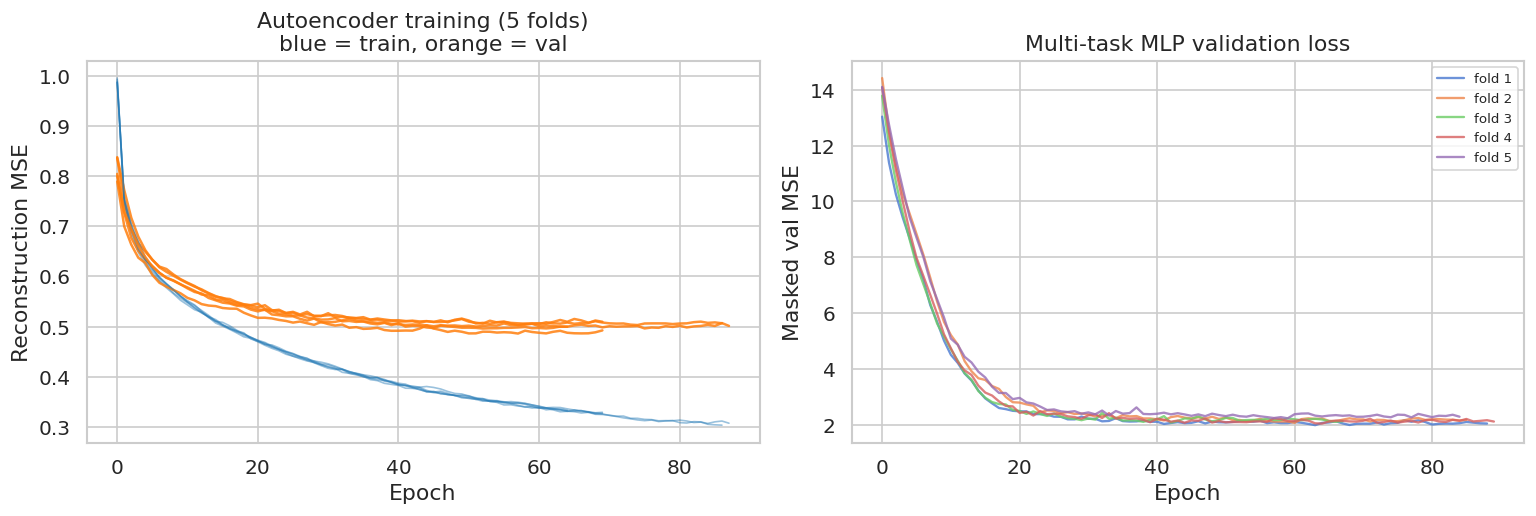

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Autoencoder reconstruction curves (one per fold).
for k, hist in enumerate(ae_hist):
    tr_l = [h[0] for h in hist]
    va_l = [h[1] for h in hist]
    axes[0].plot(tr_l, alpha=0.45, lw=1, color="tab:blue")
    axes[0].plot(va_l, alpha=0.85, lw=1.5, color="tab:orange")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Reconstruction MSE")
axes[0].set_title("Autoencoder training (5 folds)\nblue = train, orange = val")

# Multi-task vs single-task training curves.
for k, hist in enumerate(mt_hist):
    axes[1].plot([h[1] for h in hist], alpha=0.8, lw=1.4, label=f"fold {k+1}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Masked val MSE")
axes[1].set_title("Multi-task MLP validation loss")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "phase3_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

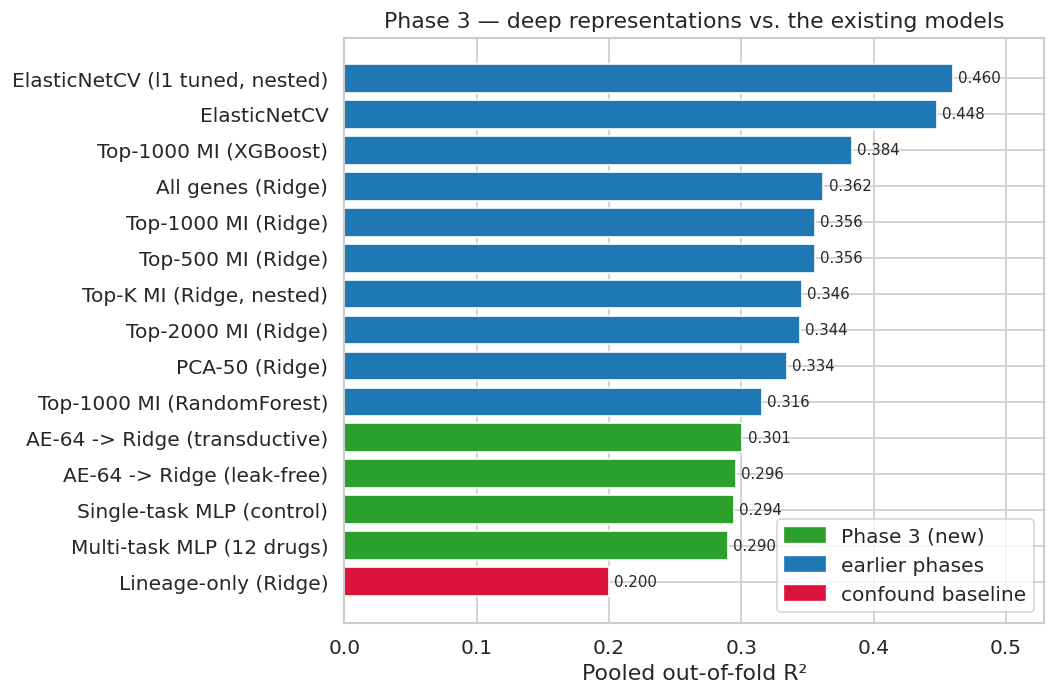

In [11]:
top = comparison.iloc[::-1]          # every model, baseline included
is_new = top["model"].isin(phase3["model"])
colors = ["tab:green" if n else ("crimson" if "Lineage-only" in m else "tab:blue")
          for n, m in zip(is_new, top["model"])]

plt.figure(figsize=(9, 6))
plt.barh(top["model"], top["R2_pooled_oof"], color=colors)
for i, v in enumerate(top["R2_pooled_oof"]):
    plt.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=9)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["tab:green", "tab:blue", "crimson"]]
plt.legend(handles, ["Phase 3 (new)", "earlier phases", "confound baseline"], loc="lower right")
plt.xlabel("Pooled out-of-fold R²")
plt.title("Phase 3 — deep representations vs. the existing models")
plt.xlim(0, max(0.5, comparison["R2_pooled_oof"].max() * 1.15))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "phase3_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Summary

Fill in from the numbers printed above — and **be honest if nothing beat ElasticNet**. At n ≈ 694
with p ≫ n that is the expected outcome, and a clean negative result is a real finding, not a
failure. See `EXPERIMENTS.md` for the written-up Phase 3 entry.